# 02 - Data Loading

Streams BridgeData V2 episodes from the public GCS mirror, extracts initial
frames, instructions and early-motion ground truth, and caches each frame into
one of two roles.

- **Construction.** Base frames the experiments are built from. A constructed
  trial composites a second instance of the manipulated object into the frame and
  writes its own instruction, so a base frame needs only a nameable, liftable
  object. 
- **Validation.** Frames kept exactly as recorded, supplying the
  axis-identification test in Notebook 03, which locates the lateral action
  channel through first-action object tracking. 
  
Frames selected for one set are not used in the other. Assignment happens here, once, and is recorded in the manifest `split` column.

This notebook uses only the TensorFlow/TFDS stack. The model is never loaded here.


## 1. Dependencies

TensorFlow Datasets is usable only against a bounded range of protobuf runtimes,
and the two edges fail differently. Below `6.31.1` the `tensorflow-metadata`
generated code refuses to run and TFDS raises a `VersionError` on import. From
protobuf `7` upward the import succeeds and streaming fails later inside
`builder_from_directory`, because protobuf 7 removed `FieldDescriptor.label`, which
released TFDS reads dataset metadata through. The cell below installs a runtime
inside that window when the current one falls outside it, and stops the notebook
rather than continuing, since protobuf caches its generated modules for the life of
the interpreter and the change cannot take effect in the running session.

In [1]:
import re, subprocess, sys
import google.protobuf as _pb

# Mirrors data.PROTOBUF_MIN and data.PROTOBUF_MAX_EXCLUSIVE
PROTOBUF_SPEC = 'protobuf>=6.31.1,<7'
_version = tuple(int(x) for x in re.findall(r'\d+', _pb.__version__)[:3])

if not ((6, 31, 1) <= _version < (7, 0, 0)):
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', PROTOBUF_SPEC],
                   check=True)
    raise RuntimeError(
        f'protobuf {_pb.__version__} is outside the window TensorFlow Datasets '
        f'supports, so {PROTOBUF_SPEC} has been installed. Restart the session '
    )
print(f'protobuf {_pb.__version__} OK')

protobuf 6.33.6 OK


## 2. Mount Drive 

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import os
# The v2 generation holds the harvest, the constructed set, the prediction log,and the exported pairs.
CACHE_DIR = '/content/drive/MyDrive/openvla_cache/v2/bridge'
os.makedirs(CACHE_DIR, exist_ok=True)
print('cache ->', CACHE_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
cache -> /content/drive/MyDrive/openvla_cache/v2/bridge


## 3. Import `data.py`

Clones the project code from GitHub into the runtime and imports the loader,
inference, and logging functions from there, so the code always matches the
pushed commit.


In [3]:
import sys, os, importlib, subprocess

REPO_URL = 'https://github.com/LewisTL/ECS8056.git'
BRANCH = 'master'
REPO_DIR = '/content/ECS8056'

def sync_repo():
    """Clone or hard-refresh the repository so it matches origin/BRANCH."""
    token = os.environ.get('GITHUB_TOKEN', '')
    url = REPO_URL.replace('https://', f'https://{token}@') if token else REPO_URL
    if os.path.isdir(os.path.join(REPO_DIR, '.git')):
        subprocess.run(['git', '-C', REPO_DIR, 'remote', 'set-url', 'origin', url],
                       check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'fetch', '--quiet', '--depth', '1',
                        'origin', BRANCH], check=True)
        subprocess.run(['git', '-C', REPO_DIR, 'reset', '--hard', '--quiet',
                        f'origin/{BRANCH}'], check=True)
    else:
        subprocess.run(['git', 'clone', '--quiet', '--depth', '1', '--branch',
                        BRANCH, url, REPO_DIR], check=True)
    return subprocess.run(['git', '-C', REPO_DIR, 'rev-parse', '--short', 'HEAD'],
                          capture_output=True, text=True).stdout.strip()


commit = sync_repo()
module_dir = REPO_DIR
if module_dir not in sys.path:
    sys.path.insert(0, module_dir)
for _m in ('model', 'data', 'export_pairs', 'detect_duplicates'):
    sys.modules.pop(_m, None)
importlib.invalidate_caches()

import data
from data import (DEFAULT_CONSTRUCTION_TARGET, DEFAULT_VALIDATION_TARGET,
                  SPLIT_CONSTRUCTION, SPLIT_VALIDATION, classify_instruction,
                  harvest, load_manifest, read_harvest_state, review_summary,
                  split_counts, stream_episodes, validation_eligible)
print(f'imported data.py from {module_dir} @ {commit}')


imported data.py from /content/ECS8056 @ d4eb1f2


## 4. Stream a small slice and inspect extraction

Pulls a handful of episodes to confirm the keys resolve and the early-motion
ground truth is non-zero (the first transition is a recorded no-op and is
skipped). Nothing is cached here, this slice only checks that extraction works
before a long harvest is started.

TFDS is imported lazily by `stream_episodes`, so this is the first cell to load
TensorFlow. 


In [4]:
import numpy as np
sample = list(stream_episodes(n=8, extract_grasp=False))
for r in sample:
    role = SPLIT_VALIDATION if validation_eligible(r.instruction) else SPLIT_CONSTRUCTION
    print(f'ep {r.episode_index:>5} | steps={r.num_steps:>3} | {role:>12} | '
          f'gt_xyz={np.round(r.gt_vector[:3], 4)} | {r.instruction}')

ep     0 | steps= 38 | construction | gt_xyz=[-0.0868  0.0915 -0.0258] | Place the can to the left of the pot.
ep     1 | steps= 32 | construction | gt_xyz=[ 0.0585  0.0423 -0.044 ] | Move the silver pot from in front of the red can, to next to the blue towel at the front edge of the table.
ep     2 | steps= 32 | construction | gt_xyz=[-0.0676 -0.0769  0.0369] | Slide the cloth diagonally to the front of the spoon
ep     3 | steps= 22 | construction | gt_xyz=[ 0.0084  0.0017 -0.0229] | put knife on cutting board
ep     4 | steps= 48 |   validation | gt_xyz=[-0.063   0.1333 -0.0066] | Move the kadai and place it at the right edge of the table.
ep     5 | steps= 27 | construction | gt_xyz=[-0.069 -0.036 -0.06 ] | Put the banana on the green cloth
ep     6 | steps= 32 | construction | gt_xyz=[ 0.068  -0.1475 -0.0065] | Put the napkin in the bottom right hand corner of the table.
ep     7 | steps= 47 | construction | gt_xyz=[-0.0772 -0.1022  0.0064] | place the silver pot on the yellow nap

## 5. How the text heuristic reads the slice

Reports the tags behind the role assignment. The tags remain informative in their
own right, since they describe what the corpus says.


In [5]:
for r in sample:
    t = r.tags
    print(f'multi={t.is_multi_object!s:5} spatial={t.has_spatial!s:5} '
          f'transfer={t.has_transfer!s:5} [{t.matched or "-"}] {r.instruction}')

multi=True  spatial=True  transfer=False [left|to the left] Place the can to the left of the pot.
multi=True  spatial=True  transfer=True  [front|next to|in front of|transfer] Move the silver pot from in front of the red can, to next to the blue towel at the front edge of the table.
multi=True  spatial=True  transfer=False [front] Slide the cloth diagonally to the front of the spoon
multi=True  spatial=False transfer=True  [transfer] put knife on cutting board
multi=True  spatial=True  transfer=False [right] Move the kadai and place it at the right edge of the table.
multi=True  spatial=False transfer=True  [transfer] Put the banana on the green cloth
multi=True  spatial=True  transfer=True  [bottom|right|transfer] Put the napkin in the bottom right hand corner of the table.
multi=True  spatial=False transfer=True  [transfer] place the silver pot on the yellow napkin


## 6. Size the harvest

The validation rate decides how long the harvest has to run, so it is measured on
a slice before committing to a full pass. Nothing here is cached. The frames are
discarded and the same episodes are streamed again by the harvest.

Streaming is sequential, so the episode budget is the cost. The estimate below
turns the observed rate into the number of episodes the validation target implies.


In [6]:
N = 300
counts = {'total': 0, 'validation_eligible': 0, 'spatial': 0, 'transfer': 0}
for r in stream_episodes(n=N, extract_grasp=False):
    counts['total'] += 1
    if validation_eligible(r.instruction): counts['validation_eligible'] += 1
    if r.tags.has_spatial:                 counts['spatial'] += 1
    if r.tags.has_transfer:                counts['transfer'] += 1

rate = counts['validation_eligible'] / counts['total']
print(counts)
print(f"validation eligible: {rate:.2%} | spatial: {counts['spatial']/counts['total']:.1%} "
      f"| transfer: {counts['transfer']/counts['total']:.1%}")
if rate:
    print(f"reaching {DEFAULT_VALIDATION_TARGET} validation scenes implies roughly "
          f"{int(DEFAULT_VALIDATION_TARGET / rate):,} episodes streamed")
else:
    print('no eligible instruction in this slice; widen N before sizing the harvest')

{'total': 300, 'validation_eligible': 16, 'spatial': 119, 'transfer': 140}
validation eligible: 5.33% | spatial: 39.7% | transfer: 46.7%
reaching 50 validation scenes implies roughly 937 episodes streamed


## 7. Harvest into the two roles

Streams forward from wherever the last run stopped, assigns each frame its role,
and appends it to the manifest. Safe to run repeatedly as frames already cached are
skipped, rows are appended in small batches, and the stream position is recorded
alongside them, so a session that ends early costs only the current batch.

The position has to be recorded rather than inferred, because once the construction
pool is full the stream continues past frames that are cached by neither role, and
the highest cached index would understate how far it reached.


In [7]:
EPISODES = 4000  

summary = harvest(
    CACHE_DIR,
    episodes=EPISODES,
    validation_target=DEFAULT_VALIDATION_TARGET,
    construction_target=DEFAULT_CONSTRUCTION_TARGET,
)
print('manifest:', summary['manifest_path'])

[harvest] streaming train[14881:18881] -> /content/drive/MyDrive/openvla_cache/v2/bridge
[harvest_records] 25 streamed, 897 validation, 14009 construction
[harvest_records] 50 streamed, 901 validation, 14030 construction
[harvest_records] 75 streamed, 903 validation, 14053 construction
[harvest_records] 100 streamed, 905 validation, 14076 construction
[harvest_records] 125 streamed, 906 validation, 14100 construction
[harvest_records] 150 streamed, 906 validation, 14125 construction
[harvest_records] 175 streamed, 907 validation, 14149 construction
[harvest_records] 200 streamed, 911 validation, 14170 construction
[harvest_records] 225 streamed, 914 validation, 14192 construction
[harvest_records] 250 streamed, 915 validation, 14216 construction
[harvest_records] 275 streamed, 917 validation, 14239 construction
[harvest_records] 300 streamed, 918 validation, 14263 construction
[harvest_records] 325 streamed, 920 validation, 14286 construction
[harvest_records] 350 streamed, 921 validat

In [8]:
state = read_harvest_state(CACHE_DIR)
totals = split_counts(load_manifest(CACHE_DIR))
print(f"episodes streamed in total: {state['episodes_streamed']:,}, "
      f"next run starts at {state['next_split_start']:,}")
print('cached by role:', totals)
print(f"validation {totals.get(SPLIT_VALIDATION, 0)}/{DEFAULT_VALIDATION_TARGET}, "
      f"construction {totals.get(SPLIT_CONSTRUCTION, 0)}/{DEFAULT_CONSTRUCTION_TARGET}")
if totals.get(SPLIT_VALIDATION, 0) < DEFAULT_VALIDATION_TARGET:
    print('re-run the harvest cell to continue, the construction pool may already '
          'be full, in which case only validation frames are still being kept')

episodes streamed in total: 17,035, next run starts at 17,035
cached by role: {'construction': 16000, 'validation': 1035}
validation 1035/50, construction 16000/16000


## 8. Verify the cache

Reads the manifest back and shows a few frames from each role. The check on the
text heuristic is that the validation frames really do read as scenes where a
lateral term selects between candidate objects.


17035 cached frames: {'construction': 16000, 'validation': 1035}
validation: 1035 frames, categories {'referent_selection': 1035}
construction: 16000 frames, categories {'placement_relation': 2743, 'referent_selection': 3181, 'other': 10076}


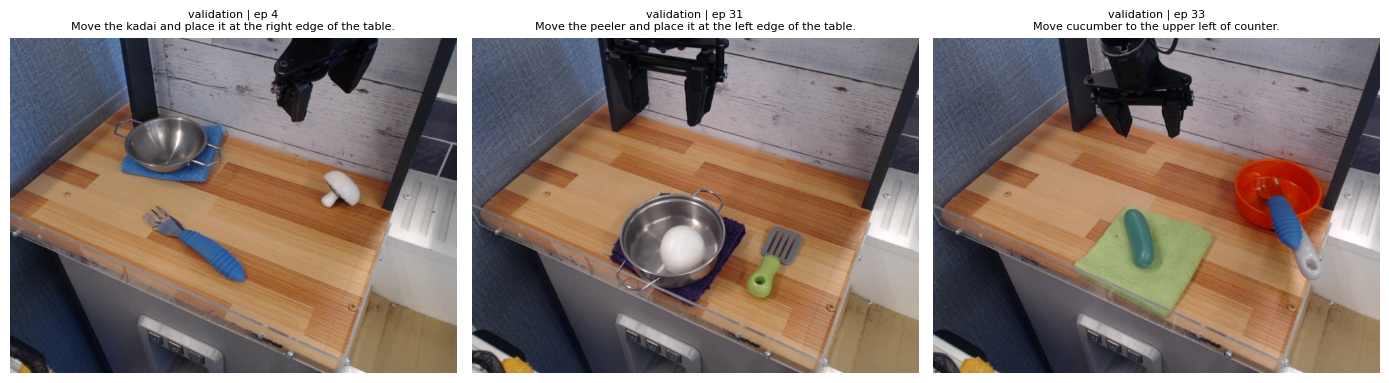

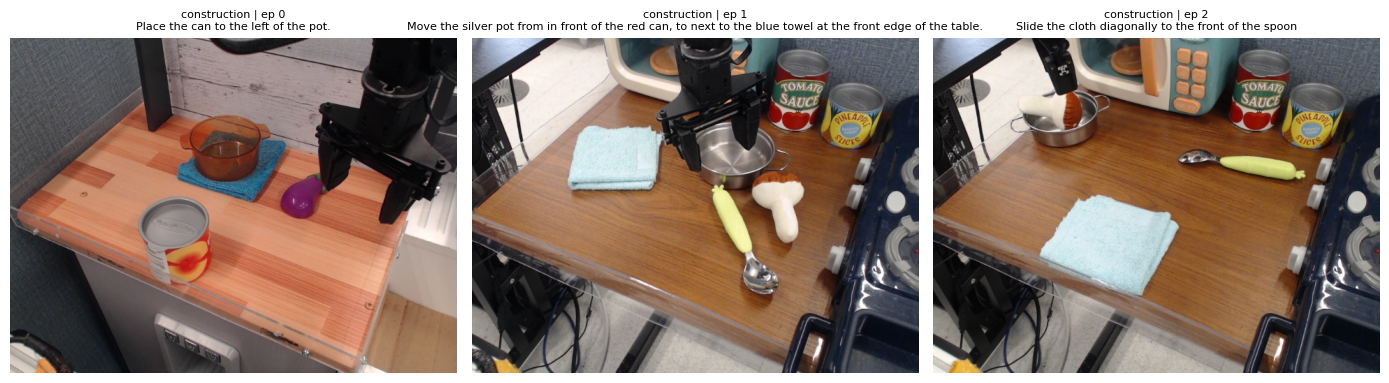

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter

rows = load_manifest(CACHE_DIR)
print(f'{len(rows)} cached frames:', split_counts(rows))

# Category mix within each role. Reads category_manual when set (manual
# correction), falling back to the heuristic category, matching the convention
# downstream code follows.
for role in (SPLIT_VALIDATION, SPLIT_CONSTRUCTION):
    subset = [r for r in rows if r['split'] == role]
    categories = Counter(r['category_manual'] or r['category'] for r in subset)
    print(f'{role}: {len(subset)} frames, categories {dict(categories)}')

for role in (SPLIT_VALIDATION, SPLIT_CONSTRUCTION):
    show = [r for r in rows if r['split'] == role][:3]
    if not show:
        continue
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, row in zip(axes.ravel(), show):
        ax.imshow(Image.open(os.path.join(CACHE_DIR, row['image_path'])))
        ax.axis('off')
        ax.set_title(f"{role} | ep {row['episode_index']}\n{row['instruction']}",
                     fontsize=8)
    for ax in axes.ravel()[len(show):]:
        ax.axis('off')
    plt.tight_layout(); plt.show()

## 9. Validation pool for the axis-identification test

The validation role supplies unaltered frames to Notebook 03. This cell
reports the current pool. Duplicate-target labels from the next section decide
which scenes Notebook 03 excludes (`yes`: two instances, term-free instruction
ambiguous).


In [10]:
validation_rows = [r for r in load_manifest(CACHE_DIR) if r['split'] == SPLIT_VALIDATION]
print('validation frames:', len(validation_rows))
print('duplicate_target:', dict(Counter(r.get('duplicate_target', '') for r in validation_rows)))


validation frames: 1035
feasible_both: {'no': 4, 'unreviewed': 1031}
Open 04_validation_set_review.ipynb for iterative feasibility review.


## 10. Automated duplicate-target proposal

This section proposes the `duplicate_target` label automatically with an
open-vocabulary detector (OWLv2). For each `referent_selection` scene the target
noun is extracted from the instruction, its instances are counted in the cached
frame, and the second-highest detection score decides `yes`, `no`, or `unclear`.
A `yes` proposal excludes the scene from the first-action gate, because two
instances make a term-free instruction ambiguous. Notebook 03 re-detects every
remaining validation frame and keeps those with exactly one instance. The pass
writes back through the manifest, so it is restart-safe and only touches scenes
still `unreviewed` for `duplicate_target`.

The pass runs over the validation frames, inheriting the review scope. The
constructed set does not need it, a second instance is put there deliberately and
whether it reads as one is what the approval screen judges.


In [11]:
import importlib

import detect_duplicates
importlib.reload(detect_duplicates)
from detect_duplicates import run_auto_pass
from data import CATEGORY_REFERENT

summary = run_auto_pass(
    CACHE_DIR,
    categories=(CATEGORY_REFERENT,),
    only_pairable=True,
    limit=None,
)
print('auto-pass proposals:', summary)

rev = review_summary(CACHE_DIR)
print(f"validation frames in scope: {rev['in_scope']} of {rev['total']} cached")
print(f"duplicate_target yes (excluded from the tracking gate): "
      f"{rev['referent_pairable_dup_yes']}")
print(f"duplicate_target unclear: {rev['referent_pairable_dup_unclear']}")
print(f"duplicate_target still unreviewed: "
      f"{rev['referent_pairable_dup_unreviewed']}")
print(f"duplicate_source breakdown: {rev['duplicate_source']}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_token.py:99: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/425 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/67.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/121 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/620M [00:00<?, ?B/s]

[update_manifest_annotations] updated 141 rows in /content/drive/MyDrive/openvla_cache/v2/bridge/manifest.csv
[run_auto_pass] 141 scenes -> yes=1 no=112 unclear=28 (noun_failures=0)
auto-pass proposals: {'total': 141, 'yes': 1, 'no': 112, 'unclear': 28, 'noun_failures': 0, 'thresholds': {'score_thresh': 0.1, 'high': 0.3, 'low': 0.15}}
validation frames in scope: 1035 of 17035 cached
primary_eligible (referent, feasible_both=yes, duplicate_target=yes): 0
duplicate_target awaiting confirmation (unclear): 223
duplicate_target still unreviewed: 0
duplicate_source breakdown: {'manual': 4, 'auto': 1031}
